In [320]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

In [263]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")
FOLDER_TMP      = os.getenv("FOLDER_TMP")

SEED            = int(os.getenv("SEED"))

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

🔌 [OK] Conexión establecida con TimescaleDB.


In [264]:
SQL='select * from vectores'
df = pd.read_sql(SQL, engine)


In [265]:
lista_label = df['label'].unique().tolist()

In [266]:
len(lista_label)

54

In [267]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()
df_result['split_type'] = 'unknown'

In [268]:
df_result

,vector_id,execution_name,label,split_type
0,54,light-oauth2-data-1719592986.tar,correct,unknown
1,55,light-oauth2-data-1719592986.tar,correct,unknown
2,56,light-oauth2-data-1719592986.tar,correct,unknown
3,57,light-oauth2-data-1719592986.tar,correct,unknown
4,58,light-oauth2-data-1719592986.tar,correct,unknown
...,...,...,...,...
90185,90239,light-oauth2-data-1725866154.tar,delete_user_404_no_user,unknown
90186,90240,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,unknown
90187,90241,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,unknown
90188,90242,light-oauth2-data-1725866154.tar,update_password_400_not_match,unknown


# <span style="color:#2ca02c">1. Separamos conjutnos de train, val y test</span>

<span style="color:#2ca02c">Por cada label dividimos los datos en train, val y test</span>


In [269]:
dic_idx_train = {}
dic_idx_resto = {}
dic_idx_val   = {}
dic_idx_test  = {}

In [270]:
for label in lista_label:
    indices = df[ df['label']== label ].index.values
    idx_train, idx_resto = train_test_split(indices   , test_size=0.4 , random_state=SEED)
    idx_val,   idx_test  = train_test_split(idx_resto , test_size=0.5 , random_state=SEED)
    df_result.loc[idx_train , 'split_type'] = 'train'
    df_result.loc[idx_val   , 'split_type'] = 'val'
    df_result.loc[idx_test  , 'split_type'] = 'test'
    dic_idx_train[label] = idx_train
    dic_idx_resto[label] = idx_resto
    dic_idx_val[label]   = idx_val
    dic_idx_test[label]  = idx_test

df_reparto = pd.DataFrame({
    'Cantidad': df_result['split_type'].value_counts(),
    'Porcentaje (%)': (df_result['split_type'].value_counts(normalize=True) * 100).round(2)
})

print("Reparto porcentual de los datos:")
display(df_reparto)

Reparto porcentual de los datos:


,Cantidad,Porcentaje (%)
split_type,,
train,54093,59.98
test,18058,20.02
val,18039,20.00


In [271]:
df_result

,vector_id,execution_name,label,split_type
0,54,light-oauth2-data-1719592986.tar,correct,test
1,55,light-oauth2-data-1719592986.tar,correct,train
2,56,light-oauth2-data-1719592986.tar,correct,train
3,57,light-oauth2-data-1719592986.tar,correct,test
4,58,light-oauth2-data-1719592986.tar,correct,train
...,...,...,...,...
90185,90239,light-oauth2-data-1725866154.tar,delete_user_404_no_user,train
90186,90240,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,val
90187,90241,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,train
90188,90242,light-oauth2-data-1725866154.tar,update_password_400_not_match,val


In [272]:
# indices_correct = df[ df['label']=='correct'].index.values
# idx_correct_train, idx_correct_resto = train_test_split(indices_correct, test_size=0.4, random_state=SEED)
# idx_correct_val, idx_correct_test    = train_test_split(idx_correct_resto, test_size=0.5, random_state=SEED)
# df_result.loc[idx_correct_train , 'split_type'] = 'train'
# df_result.loc[idx_correct_val   , 'split_type'] = 'val'
# df_result.loc[idx_correct_test  , 'split_type'] = 'test'

<span style="color:#2ca02c"> Convetimos los vectores del df en una matriz, seran los datos que pasemos a los algoritmo   </span>


In [273]:
X_matrix = np.array(df['vector'].tolist())
X_matrix.shape

(90190, 118)

In [274]:
#idx_correct_train = df_result[(df_result['label'] == 'correct') & (df_result['split_type'] == 'train')].index.tolist()

# <span style="color:#2ca02c">2. Usamos Isolation Forest (IF) para </span>

<span style="color:#2ca02c"> Entrenamos IF con los datos del split 'train' y label 'correct'   </span>


In [275]:
idx_correct_train = dic_idx_train['correct']
idx_correct_val   = dic_idx_val['correct']
idx_correct_test  = dic_idx_test['correct']

In [276]:
len(idx_correct_train)

10231

In [277]:
idx_correct_val

array([65526, 62651, 89794, ..., 31496, 42899, 37714], shape=(3410,))

In [278]:
idx_correct_test

array([54608, 70380, 76225, ...,  5344, 50311, 71932], shape=(3411,))

In [279]:
#X_correct = df[ df['label']=='correct']['vector']

In [280]:
#X_correct_matrix = np.array(X_correct.tolist())

In [281]:
#X_correct_matrix.shape

In [282]:
X_matrix.shape

(90190, 118)

In [283]:
X_correct_train = X_matrix[idx_correct_train]
X_correct_test  = X_matrix[idx_correct_test]

In [284]:
model = IsolationForest(
    n_estimators=200, 
    max_samples='auto', 
    contamination='auto', 
    random_state=42
)

In [285]:
model.fit(X_correct_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [286]:
scores = model.decision_function(X_correct_test)

In [287]:
Y_pred = model.predict(X_correct_test)


In [288]:
Y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(3411,))

In [289]:
 df.loc[idx_correct_test].shape

(3411, 5)

In [290]:
len(Y_pred)

3411

In [291]:
df.shape

(90190, 5)

In [292]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_correct_test, 't_rel'],
    'execution_name': df.loc[idx_correct_test, 'execution_name'],
    'label': df.loc[idx_correct_test, 'label'],
    'score': scores,
    'Y_pred': Y_pred
})

In [293]:
scores.shape

(3411,)

In [294]:
df_result.loc[idx_correct_test, 'result_test1'] = Y_pred
df_result.loc[idx_correct_test, 'score_test1']  = scores

In [295]:
len(Y_pred)

3411

In [296]:
df_result

,t_rel,execution_name,label,score,Y_pred,result_test1,score_test1
54608,5.0,light-oauth2-data-1723439681.tar,correct,0.041143,1,1.0,0.041143
70380,30.0,light-oauth2-data-1724526880.tar,correct,0.122215,1,1.0,0.122215
76225,25.0,light-oauth2-data-1724919283.tar,correct,0.108039,1,1.0,0.108039
13781,35.0,light-oauth2-data-1720545248.tar,correct,0.081141,1,1.0,0.081141
34886,15.0,light-oauth2-data-1722003248.tar,correct,0.113820,1,1.0,0.113820
...,...,...,...,...,...,...,...
11580,30.0,light-oauth2-data-1720390450.tar,correct,0.123573,1,1.0,0.123573
79943,40.0,light-oauth2-data-1725178477.tar,correct,0.110533,1,1.0,0.110533
5344,45.0,light-oauth2-data-1719962050.tar,correct,0.077546,1,1.0,0.077546
50311,35.0,light-oauth2-data-1723122856.tar,correct,0.105866,1,1.0,0.105866


In [297]:
tabla_resultados = pd.crosstab(
    df_result.loc[idx_correct_test, 'label'], 
    df_result.loc[idx_correct_test, 'result_test1'],
    rownames=['Etiqueta Real'], 
    colnames=['Predicción Modelo']
)

In [298]:
tabla_resultados

Predicción Modelo,-1.0,1.0
Etiqueta Real,,
correct,82,3329


<span style="color:#2ca02c"> El modelo identifica como anomalia el 3% de los datos normales que se le proporcionan en el test  </span>

In [299]:
N_datos_test_por_anomalia = int( len(idx_correct_test)  / (len(lista_label)-1) )

In [300]:
N_datos_test_por_anomalia

64

In [301]:
idx_test =idx_correct_test.copy()
for label in lista_label:
    if label=='correct':
        continue
    if len(dic_idx_test[label])<N_datos_test_por_anomalia:
        idx_test = np.concatenate((idx_test, dic_idx_test[label]))
    else:
        #idx_test.extend(dic_idx_test[label][:N_datos_test_por_anomalia])
        # Corrección: pon los dos arrays dentro de un paréntesis
        idx_test = np.concatenate((idx_test, dic_idx_test[label][:N_datos_test_por_anomalia]))

In [302]:
len(idx_test)

6781

In [303]:
X_test  = X_matrix[idx_test]

In [304]:
scores = model.decision_function(X_test)

In [305]:
Y_pred = model.predict(X_test)


In [306]:
Y_pred

array([ 1,  1,  1, ..., -1, -1, -1], shape=(6781,))

In [307]:
 df.loc[idx_test].shape

(6781, 5)

In [308]:
len(Y_pred)

6781

In [309]:
df.shape

(90190, 5)

In [310]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_correct_test, 'execution_name'],
    'label': df.loc[idx_test, 'label'],
    'score': scores,
    'Y_pred': Y_pred
})

In [311]:
scores.shape

(6781,)

In [312]:
df_result.loc[idx_test, 'result_test2'] = Y_pred
df_result.loc[idx_test, 'score_test2']  = scores

In [313]:
df_result

,t_rel,execution_name,label,score,Y_pred,result_test2,score_test2
0,5.0,light-oauth2-data-1719592986.tar,correct,0.041143,1,1.0,0.051922
3,20.0,light-oauth2-data-1719592986.tar,correct,0.122215,1,1.0,0.091819
53,5.0,light-oauth2-data-1719594842.tar,correct,0.108039,1,1.0,0.063571
58,30.0,light-oauth2-data-1719594842.tar,correct,0.081141,1,1.0,0.092311
60,40.0,light-oauth2-data-1719594842.tar,correct,0.113820,1,1.0,0.068883
...,...,...,...,...,...,...,...
90126,10.0,light-oauth2-data-1725866154.tar,correct,-0.117863,-1,1.0,0.074272
90131,35.0,light-oauth2-data-1725866154.tar,correct,-0.153261,-1,1.0,0.080715
90133,45.0,light-oauth2-data-1725866154.tar,correct,-0.114539,-1,1.0,0.044731
90134,50.0,light-oauth2-data-1725866154.tar,correct,-0.108131,-1,-1.0,-0.060531


In [314]:
tabla_resultados = pd.crosstab(
    df_result.loc[idx_test, 'label'], 
    df_result.loc[idx_test, 'result_test2'],
    rownames=['Etiqueta Real'], 
    colnames=['Predicción Modelo']
)

In [315]:
tabla_resultados

Predicción Modelo,-1.0,1.0
Etiqueta Real,,
access_token_auth_header_error_401,64,0
access_token_authorization_form_401,64,0
access_token_client_id_not_found_404,64,0
access_token_client_secret_wrong_401,64,0
access_token_form_urlencoded_400,64,0
access_token_illegal_grant_type_400,64,0
access_token_missing_authorization_header_400,64,0
authorization_code_client_id_missing_400,64,0
authorization_code_invalid_client_id_404,64,0


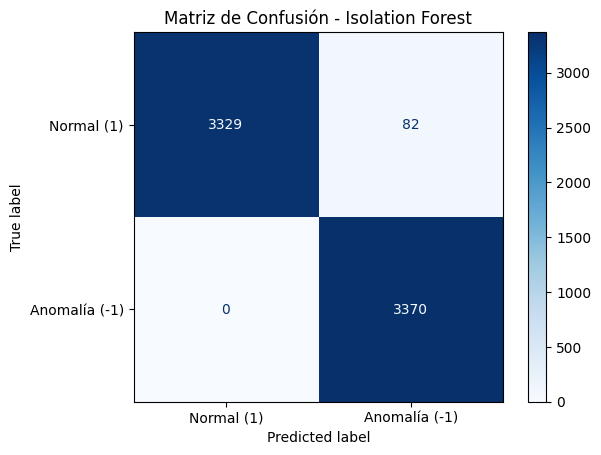

In [316]:
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 1 if x == 'correct' else -1)
y_pred = df_result.loc[idx_test, 'result_test2']

# 2. Generar la matriz
cm = confusion_matrix(y_true, y_pred, labels=[1, -1])

# 3. Visualizarla
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (1)', 'Anomalía (-1)'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Isolation Forest')
plt.show()

In [317]:
reporte = classification_report(y_true, y_pred, target_names=['Anomalía', 'Normal'])
print(reporte)

              precision    recall  f1-score   support

    Anomalía       0.98      1.00      0.99      3370
      Normal       1.00      0.98      0.99      3411

    accuracy                           0.99      6781
   macro avg       0.99      0.99      0.99      6781
weighted avg       0.99      0.99      0.99      6781



In [322]:
#hay que calcular Y_test que es la etiqueta real 1=Normal,  -1 =anomlaia

result = permutation_importance(
    model, X_test, Y_test, 
    n_repeats=10, 
    random_state=SEED, 
    n_jobs=-1
)

# Creamos el DataFrame de importancia
df_importancia = pd.DataFrame({
    'Caracteristica': X_test.columns,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=False)

print(df_importancia.head(10))

NameError: name 'Y_test' is not defined